# HVAC Hybrid Model

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

import seaborn as sns 
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [25]:
hvac_data = pd.read_csv('hvac_model_zones.csv')

In [26]:
def transform_data(df_original):
    df = df_original.copy()
    df.columns = df.columns.str.replace(r"^b'|'$|\[.*?\]", "", regex=True)
    df = df.loc[df['Environment:Site Day Type Index'] != 0]

    df["HVAC_kWh"] = df["Electricity:HVAC"] * 2.77778e-7
    df.drop(columns='Electricity:HVAC', axis=1, inplace=True)

    occupant_cols = [col for col in df.columns if 'Occupant' in col]
    df["TotalOccCount"] = df[occupant_cols].sum(axis=1)
    df.drop(columns=occupant_cols, axis=1, inplace=True)
    
    lenOfData = len(df)
    df.index = pd.date_range(start="2004-01-01 00:00:00", periods=lenOfData, freq="10min")
    return df

hvac_data = transform_data(hvac_data)

In [27]:
def add_lags(df):
    for col in df.columns:
        target_map = df[col].to_dict()
        df[f'{col}_lag1'] = (df.index - pd.Timedelta('7 days')).map(target_map)
        df[f'{col}_lag2'] = (df.index - pd.Timedelta('14 days')).map(target_map)
        df[f'{col}_lag3'] = (df.index - pd.Timedelta('21 days')).map(target_map)
    return df

hvac_data = add_lags(hvac_data)

In [28]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

hvac_data = create_features(hvac_data)

In [29]:
features = ['weekofyear',
    'hour',
    'dayofmonth',
    'month',
    'HVAC_kWh_lag3',
    'TotalOccCount_lag3',
    'TotalOccCount_lag2',
    'TotalOccCount_lag1',
    'Environment:Site Day Type Index_lag1',
    'Environment:Site Outdoor Air Drybulb Temperature_lag2',
    'Environment:Site Outdoor Air Drybulb Temperature_lag1',
    'Environment:Site Outdoor Air Wetbulb Temperature_lag1',
    'Environment:Site Outdoor Air Wetbulb Temperature_lag3',
    'HVAC_kWh_lag1',
    'HVAC_kWh_lag2']

target = 'HVAC_kWh'
    
    
def feature_selection(df):
    df = df.bfill()
    # df = df.dropna()
    X, y = df[features], df[target]
    
    return X, y

X, y = feature_selection(hvac_data)

In [30]:
def train_test_split(X, y):
    X_train, y_train = X[hvac_data.index.month <= 11], y[hvac_data.index.month <= 11]
    X_test, y_test = X[(hvac_data.index.month > 11) & (hvac_data.index.month <= 12)], y[(hvac_data.index.month > 11) & ((hvac_data.index.month <= 12))]
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = train_test_split(X, y)

In [31]:
def compute_metrics(test_data,forecast_mean):
    mae = mean_absolute_error(test_data, forecast_mean)
    mse = mean_squared_error(test_data, forecast_mean)
    rmse = np.sqrt(mse)


    metrics = {
        "mae":mae,
        "mse":mse,
        "rmse":rmse
    }

    return metrics

In [32]:
#define and train linear regression model
lin_reg_hybrid_lags = LinearRegression()
lin_reg_hybrid_lags.fit(X_train, y_train)

#Make predictions on train set and prepare data for XGBoost Model
y_train_residuals_hybrid_lags = y_train - pd.Series(lin_reg_hybrid_lags.predict(X_train), index=X_train.index)
y_train_hybrid_lags = y_train_residuals_hybrid_lags
xgb_reg_hybrid_lags = xgb.XGBRegressor(base_score=0.5,
                      booster='gbtree',
                      n_estimators=200,
                      objective='reg:squarederror',
                      max_depth=5,
                      learning_rate=0.05)
xgb_reg_hybrid_lags.fit(X_train, y_train_hybrid_lags,
       # eval_set=[(x_train, y_train)],
       verbose=100)

X_test = X_test.ffill()

y_pred_lin_reg_lags = lin_reg_hybrid_lags.predict(X_test)
y_pred_xgb_reg_lags = xgb_reg_hybrid_lags.predict(X_test)

y_pred_combined_lags = y_pred_lin_reg_lags + y_pred_xgb_reg_lags
y_pred_combined_lags = pd.Series(y_pred_combined_lags, index = X_test.index)

In [33]:
pred_df_hybrid_lags = hvac_data[(hvac_data.index.month > 11) & (hvac_data.index.month <= 12)]

In [34]:
pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags

In [35]:
# plt.figure(figsize=(15, 5))
# sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['HVAC_kWh'], label='Actual')
# sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['Predictions'], label='Predicted', dashes=(4,2))
# plt.title('HVAC Energy consumption by Hour')
# plt.legend()
# plt.show()

# compute_metrics(pred_df_hybrid_lags['HVAC_kWh'], pred_df_hybrid_lags['Predictions'])

saving the model

In [36]:
import joblib
joblib.dump(lin_reg_hybrid_lags, 'lin_reg_model.pkl')
joblib.dump(xgb_reg_hybrid_lags, 'xgb_model.pkl')

['xgb_model.pkl']

Forcasting the future

In [37]:
# Load Linear Regression model
lin_reg_hybrid_lags = joblib.load('lin_reg_model.pkl')

# Load XGBoost model
xgb_reg_hybrid_lags = joblib.load('xgb_model.pkl')


In [38]:
future = pd.date_range(
    start=X_train.index.max() + pd.Timedelta(minutes=10),
    end=X_train.index.max() + pd.Timedelta(days=7),
    freq='10min'
)

In [39]:
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
X_train['isFuture'] = False
df_and_future = pd.concat([X_train, future_df])
# df_and_future = feature_selection(pd.concat([X_train, future_df]))


In [40]:
df_and_future

,weekofyear,hour,dayofmonth,month,HVAC_kWh_lag3,TotalOccCount_lag3,TotalOccCount_lag2,TotalOccCount_lag1,Environment:Site Day Type Index_lag1,Environment:Site Outdoor Air Drybulb Temperature_lag2,Environment:Site Outdoor Air Drybulb Temperature_lag1,Environment:Site Outdoor Air Wetbulb Temperature_lag1,Environment:Site Outdoor Air Wetbulb Temperature_lag3,HVAC_kWh_lag1,HVAC_kWh_lag2,isFuture
2004-01-01 00:00:00,1,0.0,1.0,1.0,0.416009,0.0,0.0,0.0,1.0,19.816667,19.816667,17.949119,17.949119,0.416009,0.416009,False
2004-01-01 00:10:00,1,0.0,1.0,1.0,0.416009,0.0,0.0,0.0,1.0,19.816667,19.816667,17.949119,17.949119,0.416009,0.416009,False
2004-01-01 00:20:00,1,0.0,1.0,1.0,0.416009,0.0,0.0,0.0,1.0,19.816667,19.816667,17.949119,17.949119,0.416009,0.416009,False
2004-01-01 00:30:00,1,0.0,1.0,1.0,0.416009,0.0,0.0,0.0,1.0,19.816667,19.816667,17.949119,17.949119,0.416009,0.416009,False
2004-01-01 00:40:00,1,0.0,1.0,1.0,0.416009,0.0,0.0,0.0,1.0,19.816667,19.816667,17.949119,17.949119,0.416009,0.416009,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004-12-07 23:10:00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2004-12-07 23:20:00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2004-12-07 23:30:00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2004-12-07 23:40:00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [ ]:
def add_lags_test(df):
    for col in X.columns:
        target_map = df[col].to_dict()
        df[f'{col}'] = (df.index - pd.Timedelta('7 days')).map(target_map)
        df[f'{col}'] = (df.index - pd.Timedelta('14 days')).map(target_map)
        df[f'{col}'] = (df.index - pd.Timedelta('21 days')).map(target_map)
    return df

df_and_future = add_lags_test(df_and_future)

In [ ]:
def create_features_test(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df


df_and_future = create_features_test(df_and_future)
# df_and_future = df_and_future[features+['isFuture']]

KeyError: "['isFuture'] not in index"

In [ ]:
features

['weekofyear',
 'hour',
 'dayofmonth',
 'month',
 'HVAC_kWh_lag3',
 'TotalOccCount_lag3',
 'TotalOccCount_lag2',
 'TotalOccCount_lag1',
 'Environment:Site Day Type Index_lag1',
 'Environment:Site Outdoor Air Drybulb Temperature_lag2',
 'Environment:Site Outdoor Air Drybulb Temperature_lag1',
 'Environment:Site Outdoor Air Wetbulb Temperature_lag1',
 'Environment:Site Outdoor Air Wetbulb Temperature_lag3',
 'HVAC_kWh_lag1',
 'HVAC_kWh_lag2']

In [ ]:
df_and_future

,weekofyear,hour,dayofmonth,month,HVAC_kWh_lag3,TotalOccCount_lag3,TotalOccCount_lag2,TotalOccCount_lag1,Environment:Site Day Type Index_lag1,Environment:Site Outdoor Air Drybulb Temperature_lag2,Environment:Site Outdoor Air Drybulb Temperature_lag1,Environment:Site Outdoor Air Wetbulb Temperature_lag1,Environment:Site Outdoor Air Wetbulb Temperature_lag3,HVAC_kWh_lag1,HVAC_kWh_lag2
2004-01-01 00:00:00,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01 00:10:00,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01 00:20:00,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01 00:30:00,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01 00:40:00,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004-12-07 23:10:00,50,23,7,12,0.0,0.0,0.0,0.0,6.0,24.333333,24.0,19.729779,19.342139,0.0,0.0
2004-12-07 23:20:00,50,23,7,12,0.0,0.0,0.0,0.0,6.0,24.500000,24.0,19.633999,19.342045,0.0,0.0
2004-12-07 23:30:00,50,23,7,12,0.0,0.0,0.0,0.0,6.0,24.666667,24.0,19.537871,19.341944,0.0,0.0
2004-12-07 23:40:00,50,23,7,12,0.0,0.0,0.0,0.0,6.0,24.833333,24.0,19.441395,19.341842,0.0,0.0


In [ ]:
future_w_features = df_and_future.query('isFuture').copy()

UndefinedVariableError: name 'isFuture' is not defined

In [ ]:
# future_w_features = future_w_features[features]

y_pred_lin_reg_lags = lin_reg_hybrid_lags.predict(future_w_features[features])
y_pred_xgb_reg_lags = xgb_reg_hybrid_lags.predict(future_w_features[features])

y_pred_combined_lags = y_pred_lin_reg_lags + y_pred_xgb_reg_lags
y_pred_combined_lags = pd.Series(y_pred_combined_lags, index = future_w_features.index)

NameError: name 'lin_reg_hybrid_lags' is not defined

In [ ]:
hvac_data = hvac_data.loc[y_pred_combined_lags.index]

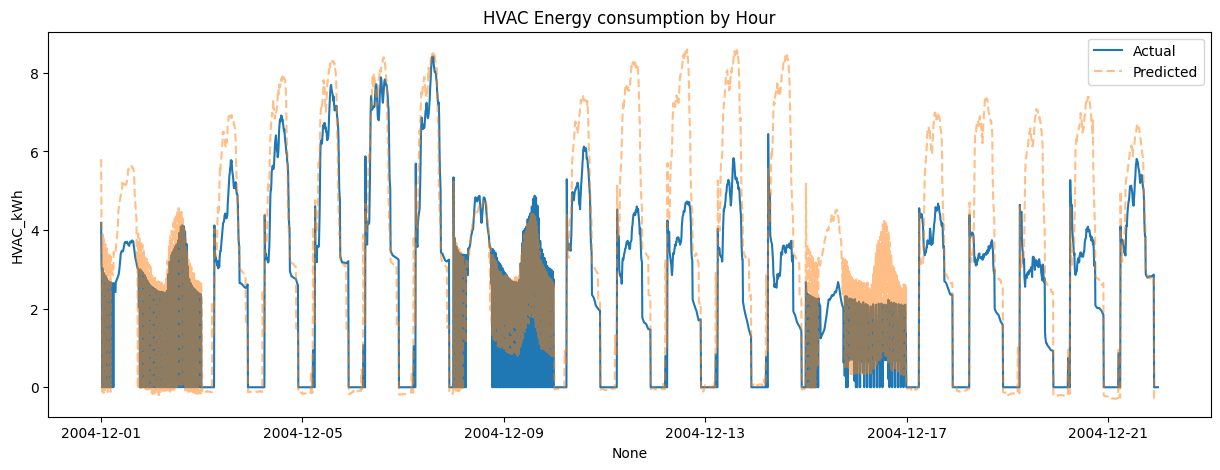

{'mae': 1.138234459441318,
 'mse': 2.692955792134341,
 'rmse': 1.6410227884262734}

In [ ]:
pred_df_hybrid_lags = hvac_data[(hvac_data.index.month > 11) & (hvac_data.index.month <= 12)]
pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags
plt.figure(figsize=(15, 5))
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['HVAC_kWh'], label='Actual')
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['Predictions'], label='Predicted', dashes=(4,2), alpha=0.5)
plt.title('HVAC Energy consumption by Hour')
plt.legend()
plt.show()
compute_metrics(pred_df_hybrid_lags['HVAC_kWh'], pred_df_hybrid_lags['Predictions'])